# Lesson 14.2 - Multi-Agent Systems (toy gridworld interaction)

This notebook implements a lightweight 2-agent gridworld to show how shared environments produce interaction effects, emergent dynamics, and reward trade-offs.
        


## Objectives

- Simulate two agents in a shared grid.
- Compare random and greedy movement policies.
- Track collisions, rewards, and interaction-induced outcomes.
        


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(123)
        


## Environment Setup


In [2]:
GRID_SIZE = 7
EPISODES = 120
MAX_STEPS = 30

ACTIONS = {
    0: (-1, 0),  # up
    1: (1, 0),   # down
    2: (0, -1),  # left
    3: (0, 1),   # right
    4: (0, 0),   # stay
}

GOAL_A = (6, 6)
GOAL_B = (0, 6)


def clamp(pos):
    r, c = pos
    return (max(0, min(GRID_SIZE - 1, r)), max(0, min(GRID_SIZE - 1, c)))


def manhattan(p, q):
    return abs(p[0] - q[0]) + abs(p[1] - q[1])
        


## Agent Policies


In [3]:
def random_policy(_pos, _goal):
    return np.random.choice(list(ACTIONS.keys()))


def greedy_policy(pos, goal):
    best_a = 4
    best_d = manhattan(pos, goal)
    for a, delta in ACTIONS.items():
        nxt = clamp((pos[0] + delta[0], pos[1] + delta[1]))
        d = manhattan(nxt, goal)
        if d < best_d:
            best_d = d
            best_a = a
    return best_a
        


## Simulation Function


In [4]:
def run_episode(policy_a, policy_b):
    pos_a = (0, 0)
    pos_b = (6, 0)

    total_reward_a = 0.0
    total_reward_b = 0.0
    collisions = 0

    for _ in range(MAX_STEPS):
        act_a = policy_a(pos_a, GOAL_A)
        act_b = policy_b(pos_b, GOAL_B)

        nxt_a = clamp((pos_a[0] + ACTIONS[act_a][0], pos_a[1] + ACTIONS[act_a][1]))
        nxt_b = clamp((pos_b[0] + ACTIONS[act_b][0], pos_b[1] + ACTIONS[act_b][1]))

        if nxt_a == nxt_b:
            collisions += 1
            # collision penalty and stay in place
            total_reward_a -= 2.0
            total_reward_b -= 2.0
        else:
            pos_a, pos_b = nxt_a, nxt_b

        # step penalty encourages shorter paths
        total_reward_a -= 0.2
        total_reward_b -= 0.2

        # proximity shaping
        total_reward_a += 0.05 * (10 - manhattan(pos_a, GOAL_A))
        total_reward_b += 0.05 * (10 - manhattan(pos_b, GOAL_B))

        # terminal rewards
        if pos_a == GOAL_A:
            total_reward_a += 8.0
        if pos_b == GOAL_B:
            total_reward_b += 8.0

    return {
        "reward_a": total_reward_a,
        "reward_b": total_reward_b,
        "collisions": collisions,
    }
        


## Compare Policy Pairings


In [5]:
configs = {
    "random_vs_random": (random_policy, random_policy),
    "greedy_vs_random": (greedy_policy, random_policy),
    "greedy_vs_greedy": (greedy_policy, greedy_policy),
}

rows = []
for name, (pa, pb) in configs.items():
    for ep in range(EPISODES):
        out = run_episode(pa, pb)
        rows.append({"config": name, "episode": ep, **out})

results = pd.DataFrame(rows)
summary = (
    results.groupby("config")
    .agg(
        mean_reward_a=("reward_a", "mean"),
        mean_reward_b=("reward_b", "mean"),
        mean_collisions=("collisions", "mean"),
    )
    .reset_index()
)
summary
        


,config,mean_reward_a,mean_reward_b,mean_collisions
0,greedy_vs_greedy,-62.050000,-62.05000,28.000000
1,greedy_vs_random,143.058750,-7.45250,1.450000
2,random_vs_random,-4.975833,-4.47625,0.291667


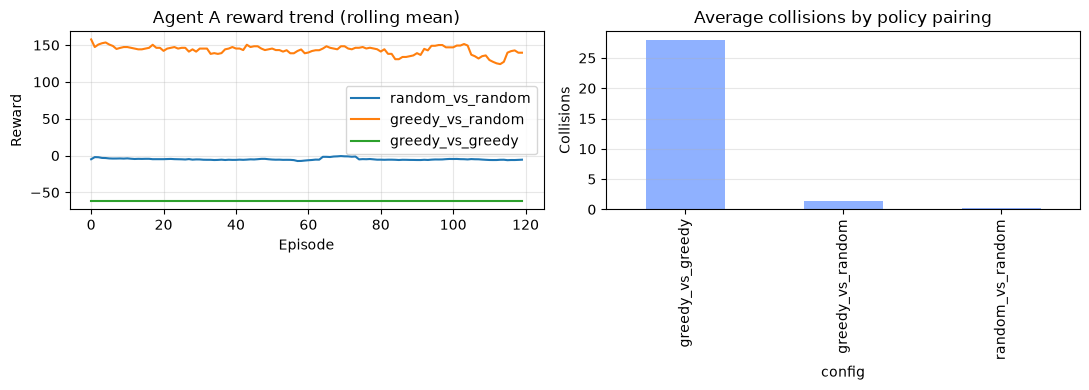

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

for cfg in results["config"].unique():
    sub = results[results["config"] == cfg]
    rolling = sub["reward_a"].rolling(10, min_periods=1).mean()
    ax[0].plot(sub["episode"], rolling, label=cfg)

ax[0].set_title("Agent A reward trend (rolling mean)")
ax[0].set_xlabel("Episode")
ax[0].set_ylabel("Reward")
ax[0].legend()
ax[0].grid(alpha=0.3)

collision_rates = summary.set_index("config")["mean_collisions"]
collision_rates.plot(kind="bar", ax=ax[1], color="#8fb1ff")
ax[1].set_title("Average collisions by policy pairing")
ax[1].set_ylabel("Collisions")
ax[1].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()
        


## Connect to Theory

- Agent outcomes depend on both policies, not one policy alone.
- Even simple local rules create interaction patterns (collisions, congestion, reward swings).
- This illustrates why multi-agent evaluation must include counterpart variability and system-level metrics.
        


## Frontier Case Studies & Exceptions

### Case Study A: Market Simulation
Pricing agents optimized local objectives and converged to undesirable global equilibria without explicit collusion.

### Case Study B: Multi-Robot Coordination
Robots with individually efficient routes caused aisle congestion. Shared penalties and coordination constraints improved throughput.

### Exceptions
If task decomposition is simple and interactions are weak, a single orchestrator can be more stable than full MAS complexity.
        


## Interview Questions & Answers

1. **Q:** Why is MAS harder than single-agent learning?  
   **A:** Other agents change the environment dynamics, creating non-stationarity.
2. **Q:** What is emergent behavior?  
   **A:** Global system patterns arising from local agent interactions.
3. **Q:** Cooperative vs competitive setup?  
   **A:** Shared objective versus conflicting objectives.
4. **Q:** What is policy coupling?  
   **A:** One agent's policy quality depends on others' behavior.
5. **Q:** Why track collisions here?  
   **A:** They represent negative externalities from uncoordinated behavior.
6. **Q:** One safety risk in MAS?  
   **A:** Harmful equilibria like cascades or tacit collusion.
7. **Q:** How do you evaluate MAS robustly?  
   **A:** Test against varied counterpart policies and environment seeds.
8. **Q:** What is credit assignment?  
   **A:** Estimating each agent's contribution to team outcomes.
9. **Q:** When avoid MAS?  
   **A:** When added coordination complexity does not improve business outcomes.
10. **Q:** Why is mechanism design relevant?  
    **A:** Incentive/rule design shapes equilibrium behavior.
11. **Q:** One practical mitigation?  
    **A:** Add system-level constraints and monitor emergent dynamics continuously.
        
